# Lab 6.01 - Regression analysis

In [2]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 1: Relation between heart weight and body weight in Cats

### Part 1

Perform a linear regression analysis on the variables body weight (`Bwt`, dependent variable) and heart weight (`Hwt`, independent variabele).


1. Import the dataset `Cats.csv`.


In [3]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables.


<Axes: xlabel='Hwt', ylabel='Bwt'>

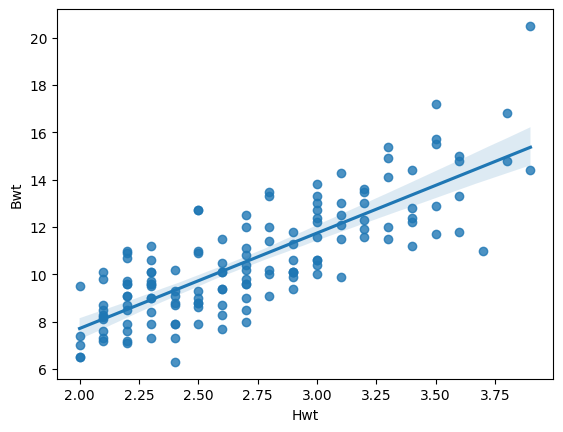

In [5]:
sns.regplot(data=cats, x='Hwt', y='Bwt')

3. Calculate and draw the regression line.


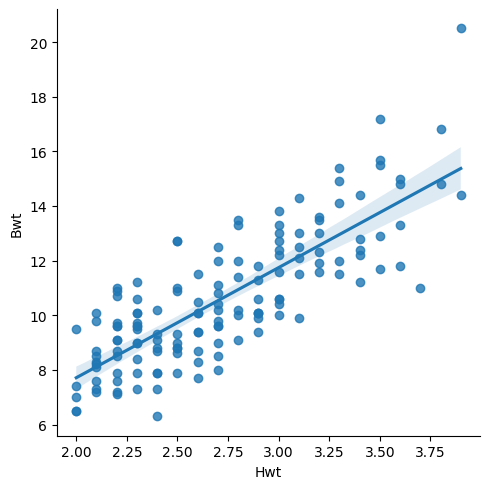

In [9]:
sns.lmplot(data=cats, x='Hwt', y='Bwt')

In [8]:
b1, b0 = np.polyfit(x=cats.Hwt, y=cats.Bwt, deg=1)

print(f"y = {b0} + {b1}*x")

y = -0.3510783771969617 + 4.031757486783179*x


4. Calculate the correlation coefficient and the coefficient of determination.

In [15]:
cor = np.corrcoef(cats.Hwt, cats.Bwt)[0][1]
print(f"R ≈ {cor:.4f}")
print(f"R² ≈ {cor**2:.4f}")

R ≈ 0.8041
R² ≈ 0.6466


5. Interpret the results from the previous steps.

In [ ]:
# increasing and strong linear regression

# R > 0 => Stijgend verband
# R ~ 0  => Sterk verband

# R² ~ .64 => 64% van de afh veranderlijke wordt verklaard door de onafh veranderlijke

### Part 2

1. Perform a linear regression analysis on the variables body weight (`Bwt`) and heart weight (`Hwt`), but this time **subdivided by gender** (`Sex`). Use the same dataset (`Cats.csv`).


In [16]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables for each gender.


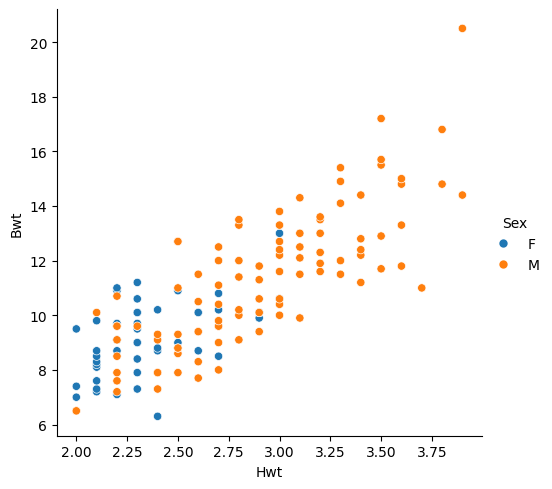

In [18]:
sns.relplot(data=cats, x='Hwt', y='Bwt', hue='Sex')

3. Calculate and draw the regression line.


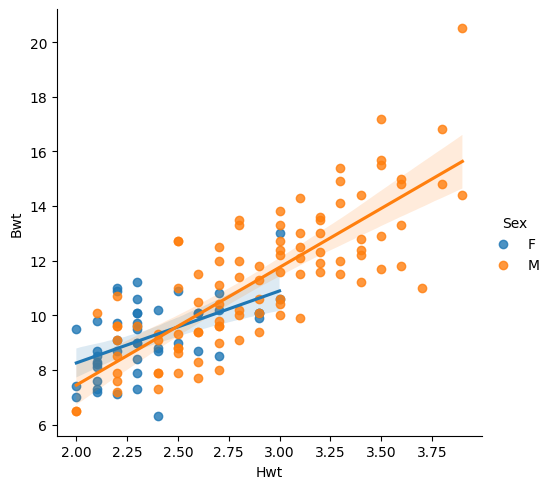

In [19]:
sns.lmplot(data=cats, x='Hwt', y='Bwt', hue='Sex')

In [22]:
male_cats = cats[cats['Sex'] == 'M']
female_cats = cats[cats['Sex'] == 'F']

reg_males = np.polyfit(male_cats.Hwt, male_cats.Bwt, deg=1)
reg_females = np.polyfit(female_cats.Hwt, female_cats.Bwt, deg=1)

print(f'Males: {reg_males}')
print(f'Females: {reg_females}')

Males: [ 4.30981888 -1.17682525]
Females: [2.63641405 2.98131238]


4. Calculate the correlation coefficient and the coefficient of determination.


In [23]:
cor_males = np.corrcoef(male_cats.Hwt, male_cats.Bwt)[0][1]
cor_females = np.corrcoef(female_cats.Hwt, female_cats.Bwt)[0][1]
print('== MALES ==')
print(f"R ≈ {cor_males:.4f}")
print(f"R² ≈ {cor_males**2:.4f}")

print('== FEMALES ==')
print(f"R ≈ {cor_females:.4f}")
print(f"R² ≈ {cor_females**2:.4f}")

== MALES ==
R ≈ 0.7930
R² ≈ 0.6289
== FEMALES ==
R ≈ 0.5320
R² ≈ 0.2831


In [24]:
cov_males = np.cov(
    male_cats.Hwt,
    male_cats.Bwt,
    ddof=1)[0][1]
cov_females = np.cov(
    female_cats.Hwt,
    female_cats.Bwt,
    ddof=1)[0][1]
print('== MALES ==')
print(f"{cov_males:.4f}")

print('== FEMALES ==')
print(f"{cov_females:.4f}")

== MALES ==
0.9419
== FEMALES ==
0.1979


5. Interpret the results from the previous steps.

In [ ]:
# Males: increasing and strong linear regression

# Females: increasing and weak linear regression

### Answers

| Selection |  $\beta_0$ | $\beta_1$ |       $R$ |     $R^2$ |
| :-------- | ---------: | --------: | --------: | --------: |
| All       | -0.3510784 | 4.0317575 | 0.8041348 | 0.6466328 |
| Male      | -1.1768253 | 4.3098189 | 0.7930443 | 0.6289193 |
| Female    |  2.9813124 |  2.636414 | 0.5320497 | 0.2830768 |
